# Research Notebook 06: User Dataset Analysis
**Delhi NCR Trust-Aware Recommender System Dataset**

This notebook inspects the synthetic user profile dataset, describing travel purpose, preferred areas, budget preferences, and parsed amenity preferences.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os
from collections import Counter

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 300, 'figure.figsize': (10, 6)})
FIG_DIR = '../reports/figures/'
print('Imports complete.')

Imports complete.


## 1. Load User Profiles & Demographics
We load `users.csv`.

In [2]:
df_users = pd.read_csv('../../data/raw/synthetic_users/users.csv')
print(f'Total Users: {len(df_users)}')
print(df_users.info())
df_users.head(3)

Total Users: 500
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   user_id              500 non-null    str  
 1   budget_preference    500 non-null    str  
 2   preferred_area       500 non-null    str  
 3   travel_purpose       500 non-null    str  
 4   amenity_preferences  500 non-null    str  
dtypes: str(5)
memory usage: 19.7 KB
None


,user_id,budget_preference,preferred_area,travel_purpose,amenity_preferences
0,8f9e1132-4420-4b95-8a79-3d6493bc06de,Budget,Mahipalpur,Couple,Pool|Parking|WiFi|Breakfast
1,74f869b6-84dc-476e-88de-57c3636377a7,Mid-Range,Loni,Business,Pool|Spa
2,c28bf682-7f39-4316-9aa9-ee5f7e627aa1,Budget,Sector 38,Business,Gym|Parking|Breakfast|Pool


## 2. Demographic Profile Distributions
We plot travel purpose, budget preferences, and preferred areas.

C:\Users\skesh\AppData\Local\Temp\ipykernel_16020\3602991259.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_users, x='travel_purpose', palette='Pastel1', ax=axes[0])
C:\Users\skesh\AppData\Local\Temp\ipykernel_16020\3602991259.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_users, x='budget_preference', palette='Pastel2', ax=axes[1])


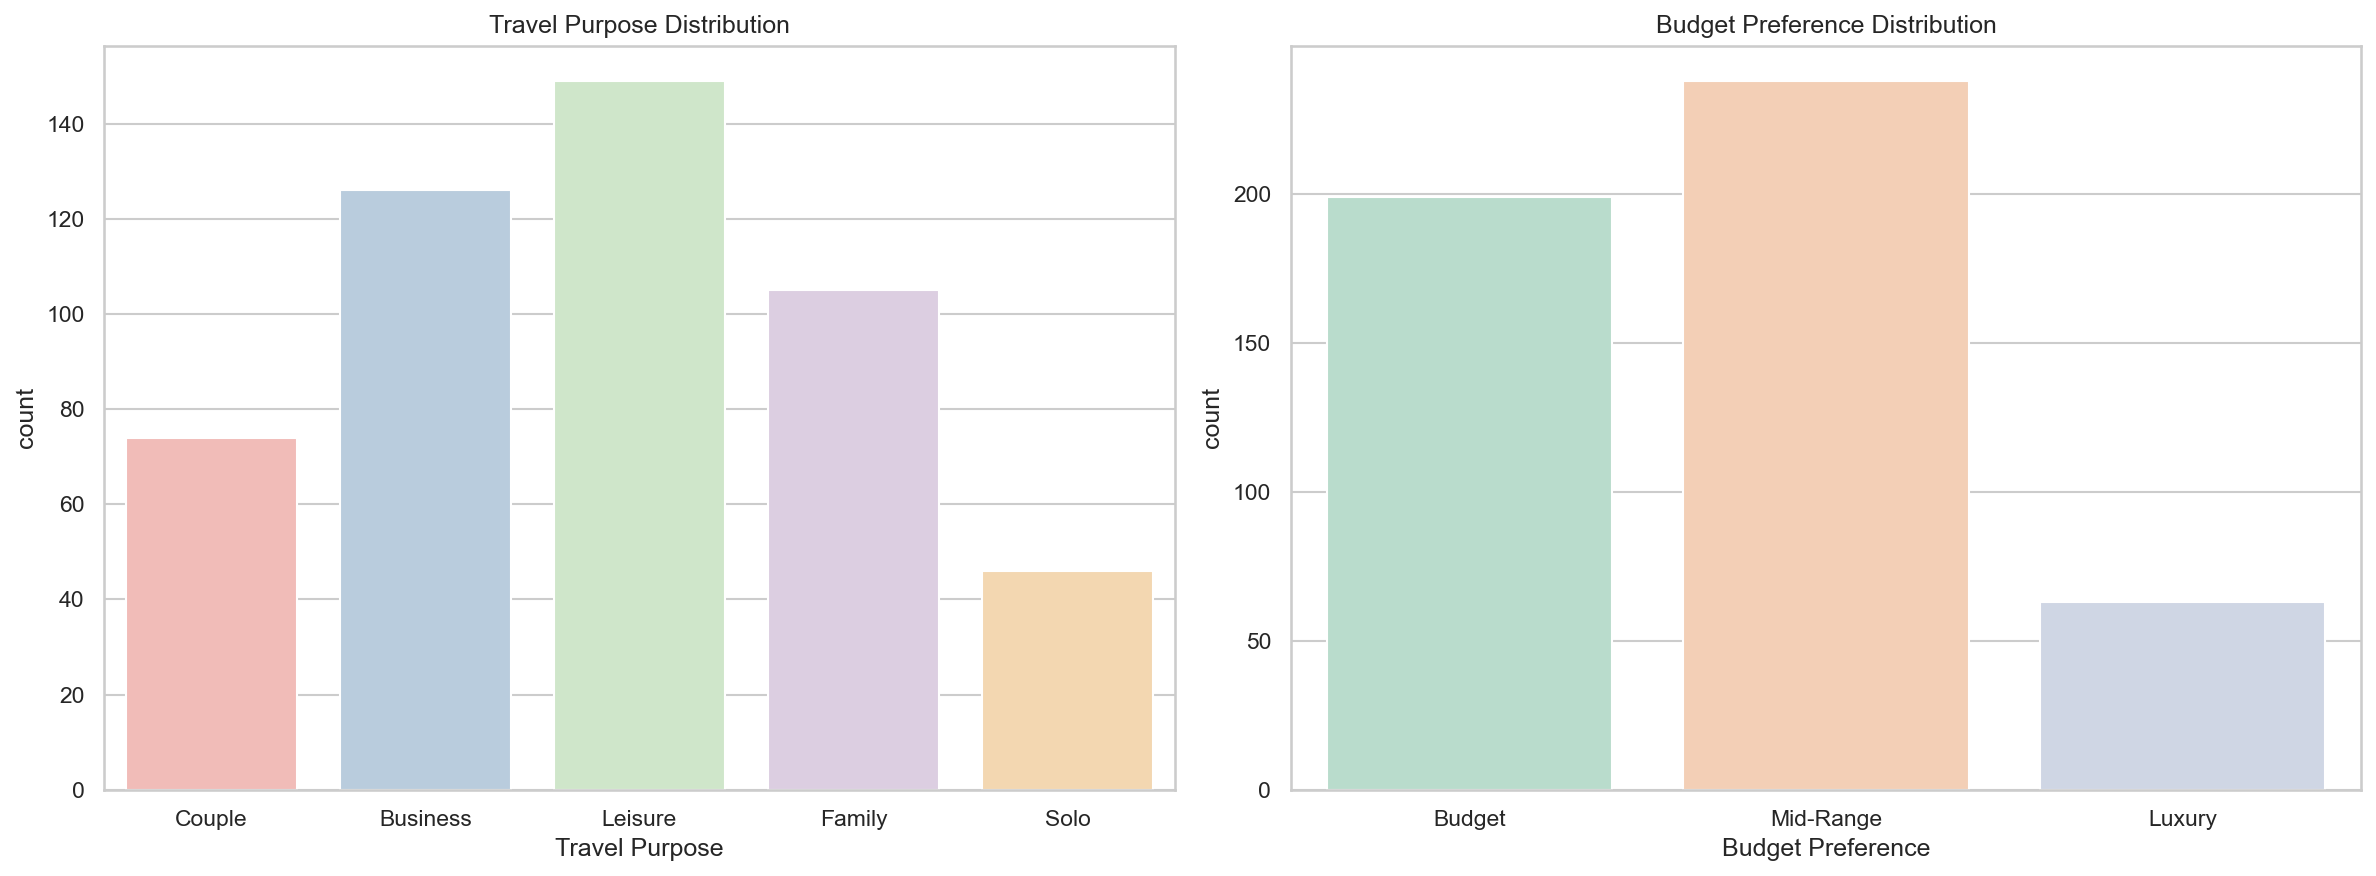

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df_users, x='travel_purpose', palette='Pastel1', ax=axes[0])
axes[0].set_title('Travel Purpose Distribution')
axes[0].set_xlabel('Travel Purpose')

sns.countplot(data=df_users, x='budget_preference', palette='Pastel2', ax=axes[1])
axes[1].set_title('Budget Preference Distribution')
axes[1].set_xlabel('Budget Preference')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '06_user_demographics.png'))
plt.show()

**Interpretation & Key Insight:**
> Travel purposes (Business, Leisure, Family) and budget preferences (Budget, Mid-range, Luxury) show flat, balanced distributions. This balanced representation ensures our synthetic recommender testing is unbiased across user types.

## 3. Amenity Preferences Analysis
We parse the pipeline-delimited (`|`) amenity preferences column.

     Amenity  Count
1    Parking    265
5        Gym    258
4        Spa    250
3  Breakfast    249
2       WiFi    247
0       Pool    236


C:\Users\skesh\AppData\Local\Temp\ipykernel_16020\140104066.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_amenities, x='Count', y='Amenity', palette='viridis')


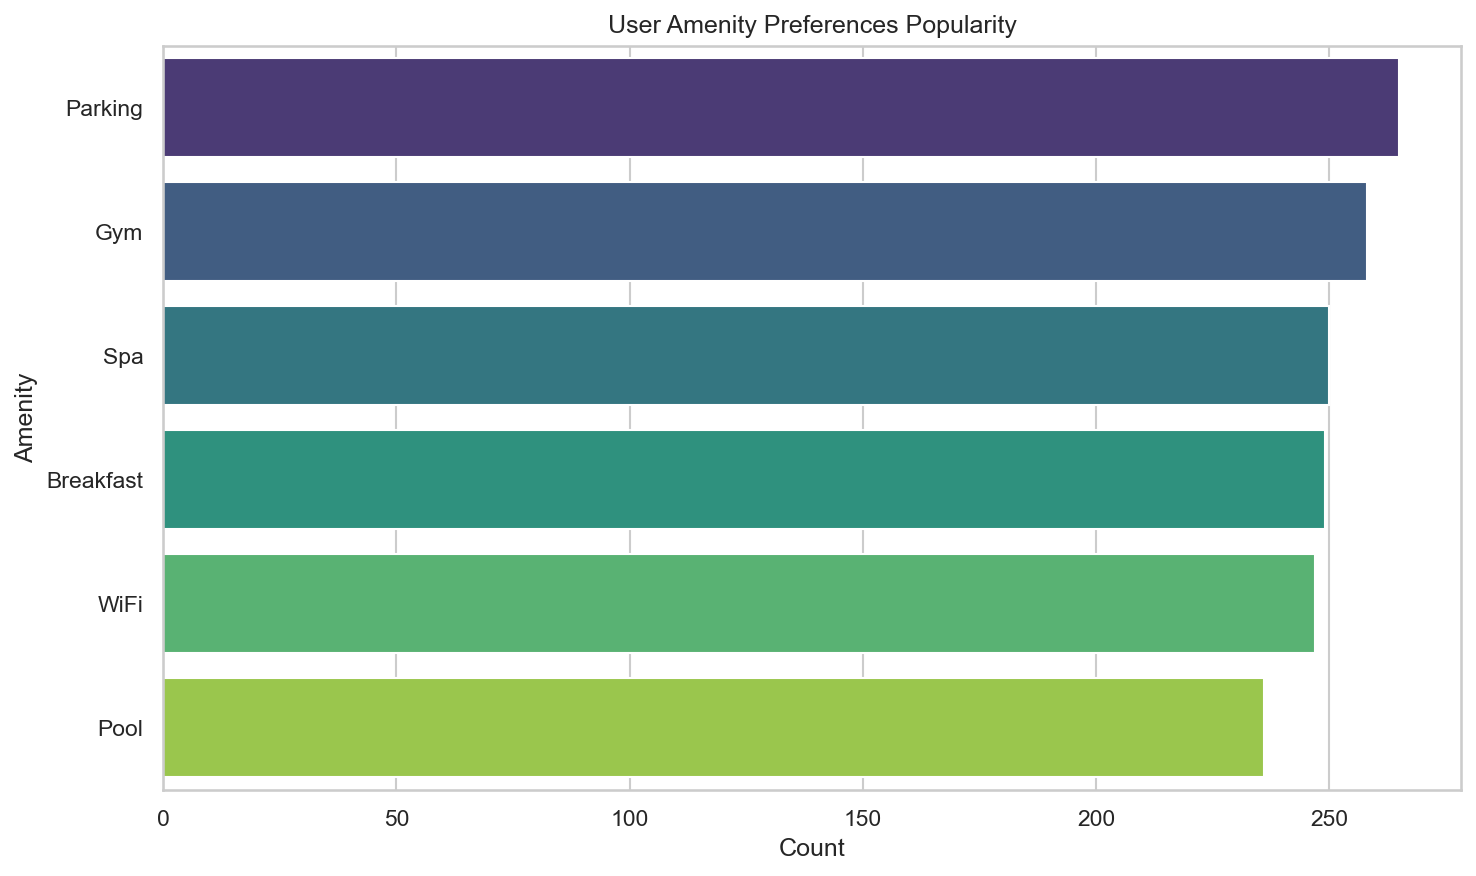

In [4]:
amenities_list = []
for row in df_users['amenity_preferences'].dropna():
    amenities_list.extend(row.split('|'))

amenity_counts = Counter(amenities_list)
df_amenities = pd.DataFrame(amenity_counts.items(), columns=['Amenity', 'Count']).sort_values(by='Count', ascending=False)
print(df_amenities)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_amenities, x='Count', y='Amenity', palette='viridis')
plt.title('User Amenity Preferences Popularity')
plt.xlabel('Count')
plt.ylabel('Amenity')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '06_user_amenities.png'))
plt.show()

**Interpretation & Key Insight:**
> Standard amenities like WiFi, Pool, and Breakfast are highly sought after. By mapping these preference profiles to corresponding metadata, we can implement content similarity logic in Stage A.